# 🌐 Module 1: The Foundations of Graph Theory

Welcome to the matrix! Before we can analyze complex social media networks or predict how a virus spreads, we need to understand the basic building blocks of a network.

In computer science and mathematics, a **Graph** is just a way to map out relationships.

Let's start by importing our essential tools. We will use `networkx` (the Python standard for network math) and `matplotlib` (for drawing the networks on our screen).

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Set up some global styling so our graphs look clean
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.facecolor'] = '#f8f9fa'

print("Libraries imported! We are ready to build.")

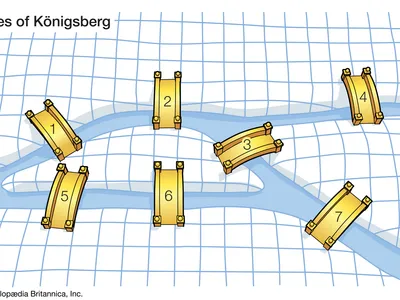

## 🌉 1. The Königsberg Bridge Problem

Graph theory was invented in 1736 to solve a puzzle. The city of Königsberg had two landmasses and two islands, connected by exactly seven bridges.

**The puzzle:** Can you walk through the city and cross every single bridge *exactly once*?

Leonhard Euler proved it was impossible. He did this by simplifying the city map: the landmasses became **Nodes** (dots), and the bridges became **Edges** (lines). Let's recreate his exact map!

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a MultiGraph (this allows multiple edges between the exact same two nodes)
K = nx.MultiGraph()

# Add the 4 landmasses (Our Nodes)
K.add_nodes_from(['North Bank', 'South Bank', 'Island A', 'Island B'])

# Add the 7 bridges (Our Edges)
bridges = [
    ('North Bank', 'Island A'), ('North Bank', 'Island A'), # 2 bridges here
    ('South Bank', 'Island A'), ('South Bank', 'Island A'), # 2 bridges here
    ('North Bank', 'Island B'),                             # 1 bridge here
    ('South Bank', 'Island B'),                             # 1 bridge here
    ('Island A', 'Island B')                                # 1 bridge between the islands
]
K.add_edges_from(bridges)

# Draw it! We set specific positions so it looks like a map
pos = {'North Bank': (0, 2), 'South Bank': (0, -2), 'Island A': (-1, 0), 'Island B': (1, 0)}

plt.figure(figsize=(8, 5))
plt.title("The Königsberg Bridge Problem", fontsize=16, fontweight='bold')

# Draw nodes and labels
nx.draw_networkx_nodes(K, pos, node_color='#a0c4ff', node_size=2500, edgecolors='black')
nx.draw_networkx_labels(K, pos, font_weight='bold')

# Draw curved edges (Fixed to prevent overlapping!)
ax = plt.gca()

# Dictionary to track how many bridges we've drawn between specific pairs
edge_count = {}

for edge in K.edges(data=True):
    source, target = edge[0], edge[1]

    # Sort the nodes so (North, Island A) is treated the same as (Island A, North)
    edge_pair = tuple(sorted((source, target)))

    # Count how many times we've seen this specific pair of nodes
    edge_count[edge_pair] = edge_count.get(edge_pair, 0) + 1

    # If it's the first bridge, curve it one way (0.2). If it's the second, curve it the other way (-0.2).
    rad = 0.2 if edge_count[edge_pair] % 2 != 0 else -0.2

    ax.annotate("",
                xy=pos[source], xycoords='data',
                xytext=pos[target], textcoords='data',
                arrowprops=dict(arrowstyle="-", color="#495057",
                                shrinkA=25, shrinkB=25,
                                connectionstyle=f"arc3,rad={rad}", linewidth=2.5))

plt.axis('off')
plt.show()

print("Notice how every landmass has an odd number of bridges connected to it. Euler proved that if more than two nodes have an odd number of connections, the puzzle is impossible!")

## 🏗️ 2. Basic Anatomy: Building a Graph from Scratch

Now let's build our own simple graph. The two core components are:
* **Nodes (Vertices):** The entities. These could be people, computers, or cities.
* **Edges (Links):** The connections between those entities.

Let's build a mini-network of 4 friends.

In [ ]:
# Create an empty, standard Graph
G = nx.Graph()

# 1. Add Nodes (Our Friends)
G.add_node("Alice")
G.add_node("Bob")
G.add_nodes_from(["Charlie", "David"]) # You can add multiple at once!

# 2. Add Edges (The Friendships)
G.add_edge("Alice", "Bob")
G.add_edges_from([
    ("Alice", "Charlie"),
    ("Bob", "Charlie"),
    ("Charlie", "David")
])

# Draw the friendship network
plt.figure(figsize=(6, 4))
plt.title("A Simple Friendship Network", fontsize=14)

# spring_layout makes the graph look organic
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='#fdffb6', node_size=2000,
        font_weight='bold', edge_color='gray', width=2)

plt.show()

print(f"Total Friends (Nodes): {G.number_of_nodes()}")
print(f"Total Friendships (Edges): {G.number_of_edges()}")

## ➡️ 3. Directed vs. Undirected Graphs

Relationships aren't always two-way streets!

* **Undirected Graph (Mutual):** Like Facebook. If Alice is friends with Bob, Bob is automatically friends with Alice. (This is what we just built above).
* **Directed Graph (One-Way):** Like Twitter or Instagram. Alice can follow Bob, but Bob doesn't have to follow Alice back.

Let's visualize a Directed Graph (called a `DiGraph` in NetworkX). Notice the arrows!

In [ ]:
# Create a Directed Graph
DG = nx.DiGraph()

# Add directional edges (Followers)
# Format: (Follower, Influencer) -> The arrow points TO the influencer
DG.add_edges_from([
    ("User A", "Influencer X"),
    ("User B", "Influencer X"),
    ("User C", "Influencer X"),
    ("Influencer X", "User A"), # The influencer followed User A back!
])

plt.figure(figsize=(6, 4))
plt.title("A Directed Graph (Follower Network)", fontsize=14)

pos_dg = nx.spring_layout(DG, seed=10)
nx.draw(DG, pos_dg, with_labels=True, node_color='#caffbf', node_size=2000,
        font_weight='bold', edge_color='black', width=1.5,
        arrowsize=20) # We make the arrows big so they are easy to see

plt.show()

## 🏋️ 4. Weights: Not All Edges Are Equal

Sometimes, we need to know the *strength* or *cost* of a relationship.

If our graph represents a map of cities, the edge shouldn't just say "Lahore is connected to Islamabad"—it should tell us the physical distance or the travel time. We do this by adding **Weights** to the edges.

In [ ]:
# Create a new graph for cities
CityGraph = nx.Graph()

# Add edges with a 'weight' attribute (let's say this represents travel time in hours)
CityGraph.add_edge("City A", "City B", weight=2)
CityGraph.add_edge("City B", "City C", weight=5)
CityGraph.add_edge("City A", "City C", weight=8)

plt.figure(figsize=(6, 4))
plt.title("A Weighted Graph (Travel Times)", fontsize=14)

# Set up layout
pos_cities = nx.spring_layout(CityGraph, seed=7)

# We want the lines to be thicker if the travel time is longer
weights = [CityGraph[u][v]['weight'] for u,v in CityGraph.edges()]

nx.draw(CityGraph, pos_cities, with_labels=True, node_color='#ffadad', node_size=2000,
        font_weight='bold', edge_color='#6c757d', width=weights)

# This special function draws the numbers directly onto the lines
edge_labels = nx.get_edge_attributes(CityGraph, 'weight')
nx.draw_networkx_edge_labels(CityGraph, pos_cities, edge_labels=edge_labels, font_size=12, font_color='red')

plt.show()

print("Notice how the line between City A and City C is much thicker (Weight=8). Later, we will use weights to calculate the absolute fastest route between two nodes!")

# 🏃‍♂️ Module 2: Movement & Metrics (Navigating the Network)

Now that we know how to build a graph, how do we move through it?

If this is a social network, how does a rumor get from Alice to David? If this is a map, what is the fastest route?

To answer these, we need to learn the rules of movement and how to measure a node's "power."

## 🚶‍♂️ 5. Walks, Paths, and Cycles

Let's define the three main ways to travel through a graph:

* **Walk:** Any sequence of nodes and edges. You can wander around and visit the same node multiple times (like a roomba cleaning a floor).
* **Path:** A strict walk where you **never** visit the same node twice. (Going straight from Point A to Point B).
* **Cycle:** A path that forms a closed loop. You start and end on the exact same node.

Let's visualize a Cycle and a Path on a simple "House" shaped graph.

In [ ]:
# Build a "House" shaped graph
House = nx.Graph()
edges = [
    ("Roof", "Top Left"), ("Roof", "Top Right"),       # The roof
    ("Top Left", "Top Right"),                         # The ceiling
    ("Top Left", "Bottom Left"), ("Top Right", "Bottom Right"), # The walls
    ("Bottom Left", "Bottom Right")                    # The floor
]
House.add_edges_from(edges)

# Define our layout so it actually looks like a house
pos_house = {"Roof": (0.5, 2), "Top Left": (0, 1), "Top Right": (1, 1),
             "Bottom Left": (0, 0), "Bottom Right": (1, 0)}

plt.figure(figsize=(10, 5))

# --- PLOT 1: A Cycle ---
plt.subplot(1, 2, 1)
plt.title("A Cycle (The Square Base)", fontsize=14)
nx.draw(House, pos_house, with_labels=True, node_color='lightgray', node_size=1500, edge_color='lightgray', width=2)

# Highlight the cycle (Top Left -> Top Right -> Bottom Right -> Bottom Left -> Top Left)
cycle_edges = [("Top Left", "Top Right"), ("Top Right", "Bottom Right"),
               ("Bottom Right", "Bottom Left"), ("Bottom Left", "Top Left")]
nx.draw_networkx_edges(House, pos_house, edgelist=cycle_edges, edge_color='red', width=4)
nx.draw_networkx_nodes(House, pos_house, nodelist=["Top Left", "Top Right", "Bottom Right", "Bottom Left"], node_color='#ff9999', node_size=1500)

# --- PLOT 2: A Path ---
plt.subplot(1, 2, 2)
plt.title("A Path (Roof to Bottom Right)", fontsize=14)
nx.draw(House, pos_house, with_labels=True, node_color='lightgray', node_size=1500, edge_color='lightgray', width=2)

# Highlight the path (Roof -> Top Left -> Bottom Left -> Bottom Right)
path_edges = [("Roof", "Top Left"), ("Top Left", "Bottom Left"), ("Bottom Left", "Bottom Right")]
nx.draw_networkx_edges(House, pos_house, edgelist=path_edges, edge_color='green', width=4)
nx.draw_networkx_nodes(House, pos_house, nodelist=["Roof", "Top Left", "Bottom Left", "Bottom Right"], node_color='#99ff99', node_size=1500)

plt.tight_layout()
plt.show()

print("Red = A Cycle (A closed loop)")
print("Green = A Path (No repeating nodes allowed!)")

## 👑 6. Degrees: Measuring Popularity

In graph theory, the "Degree" of a node is simply **the number of edges connected to it**.

If we are looking at a high school social network, the node with the highest degree is the most popular kid. Let's create a network representing a school cafeteria and calculate everyone's degree to find the VIP.

In [ ]:
Cafeteria = nx.Graph()

# Add friendships
Cafeteria.add_edges_from([
    ("Emma", "Liam"), ("Emma", "Olivia"), ("Emma", "Noah"), ("Emma", "Ava"), ("Emma", "William"), # Emma knows everyone
    ("Liam", "Noah"), ("Olivia", "Ava"), # Some mutual friends
    ("James", "Isabella"), # A quiet couple in the corner
    ("Mason", "Sophia"), ("Mason", "Mia") # A small trio
])

# Calculate Degrees
degrees = dict(Cafeteria.degree())

print("--- Cafeteria Popularity Contest (Degrees) ---")
for student, deg in sorted(degrees.items(), key=lambda item: item[1], reverse=True):
    print(f"{student} has {deg} friends.")

print(f"\nWINNER: The most popular student is {max(degrees, key=degrees.get)}!")

# Visualize it: Make the nodes bigger based on their degree!
plt.figure(figsize=(8, 5))
plt.title("Cafeteria Network (Node Size = Popularity)", fontsize=14)

pos_cafe = nx.spring_layout(Cafeteria, seed=42)

# Create a list of sizes based on the degree of each node
node_sizes = [degrees[node] * 500 for node in Cafeteria.nodes()]

nx.draw(Cafeteria, pos_cafe, with_labels=True, node_color='#a0c4ff',
        node_size=node_sizes, font_weight='bold', edge_color='gray')

plt.show()

## 📏 7. Graph Distances (Hops)

How many steps does it take to get from one node to another? This is called the **Shortest Path**, and in network math, we measure this distance in **Hops**.

Have you heard of "Six Degrees of Kevin Bacon"? It's the theory that anyone in Hollywood is connected to the actor Kevin Bacon by 6 hops or fewer.

Let's generate a random network and find the shortest path (the absolute minimum number of hops) between two distant nodes!

In [ ]:
# Generate a random "Erdős-Rényi" graph (30 nodes, 10% chance of any two nodes connecting)
RandomNet = nx.erdos_renyi_graph(n=30, p=0.1, seed=25)

# We want to find the shortest path from Node 0 to Node 29
start_node = 0
end_node = 29

try:
    # NetworkX calculates the shortest path instantly!
    shortest_path = nx.shortest_path(RandomNet, source=start_node, target=end_node)
    path_length = len(shortest_path) - 1 # Number of hops is nodes minus 1

    print(f"Path found! To get from {start_node} to {end_node}, follow this route:")
    print(f" -> ".join(map(str, shortest_path)))
    print(f"Total Distance: {path_length} hops.")

    # --- Visualization ---
    plt.figure(figsize=(9, 6))
    plt.title(f"Shortest Path: {path_length} Hops", fontsize=16, fontweight='bold')

    pos_rand = nx.spring_layout(RandomNet, seed=42)

    # 1. Draw the entire base network in a faded, light color
    nx.draw(RandomNet, pos_rand, with_labels=True, node_color='#e9ecef',
            node_size=400, edge_color='#dee2e6', font_color='gray')

    # 2. Extract just the edges that make up our shortest path
    path_edges = list(zip(shortest_path, shortest_path[1:]))

    # 3. Draw ONLY the shortest path over top in bright colors
    nx.draw_networkx_nodes(RandomNet, pos_rand, nodelist=shortest_path, node_color='#ffe066', node_size=600)
    nx.draw_networkx_nodes(RandomNet, pos_rand, nodelist=[start_node, end_node], node_color='#ff6b6b', node_size=700) # Highlight start/end in red
    nx.draw_networkx_edges(RandomNet, pos_rand, edgelist=path_edges, edge_color='#fca311', width=4)

    plt.show()

except nx.NetworkXNoPath:
    print(f"Oops! Node {start_node} and Node {end_node} are completely disconnected.")

# 🏛️ Module 3: Topologies (The Zoo of Shapes)

If you were designing a computer network for a hospital, or mapping out a power grid for a city, the *shape* of your network matters just as much as the number of nodes.

In graph theory, the specific shape or structure of a network is called its **Topology**. Let's look at the most famous network shapes and figure out their strengths and weaknesses.

## 🎯 8. Centralized vs. Decentralized Networks

Imagine a virus breaks out in a computer network, or a power line goes down. Which network survives?

1.  **Star Graph (Centralized):** One massive hub in the middle. Very fast communication, but if the center node dies, the entire network collapses.
2.  **Ring/Cycle Graph (Decentralized):** Everyone connects to two neighbors. If one line breaks, data can just travel the other way around the circle.
3.  **Grid Graph (Distributed):** Like city streets. Highly robust with many backup routes.

In [ ]:
# Generate the three topologies
Star = nx.star_graph(8) # 1 center, 8 outer nodes
Ring = nx.cycle_graph(9) # 9 nodes in a circle
Grid = nx.grid_2d_graph(3, 3) # 3x3 grid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- PLOT 1: Star ---
axes[0].set_title("Star (Centralized)", fontsize=16, fontweight='bold')
nx.draw(Star, ax=axes[0], with_labels=True, node_color='#ffadad', node_size=800, edge_color='gray')

# --- PLOT 2: Ring ---
axes[1].set_title("Ring (Decentralized)", fontsize=16, fontweight='bold')
nx.draw(Ring, nx.circular_layout(Ring), ax=axes[1], with_labels=True, node_color='#ffd6a5', node_size=800, edge_color='gray')

# --- PLOT 3: Grid ---
axes[2].set_title("Grid (Distributed)", fontsize=16, fontweight='bold')
pos_grid = {(x,y):(y,-x) for x,y in Grid.nodes()} # Organizes the grid cleanly
nx.draw(Grid, pos=pos_grid, ax=axes[2], with_labels=False, node_color='#caffbf', node_size=800, edge_color='gray')

plt.show()

print("Look at the Star graph. What happens if we delete Node 0? The whole network shatters into isolated pieces. The Grid, however, can survive many node failures!")

## 🎭 9. Bipartite Graphs (Two Distinct Worlds)

A **Bipartite Graph** is a special network that is split into two distinct groups.

The golden rule: Nodes in Group A can only connect to nodes in Group B. They can **never** connect to their own group.

This is the exact math used by recommendation engines! Netflix uses bipartite graphs to map "Users" to "Movies" to recommend what you should watch next. Let's map some Users to Social Media Topics!

In [ ]:
BipartiteNet = nx.Graph()

# Group 1: Users
users = ["User 1", "User 2", "User 3", "User 4"]
# Group 2: Topics
topics = ["#AI", "#Gaming", "#Fitness", "#Cooking"]

# Add nodes with an attribute specifying their group
BipartiteNet.add_nodes_from(users, bipartite=0)
BipartiteNet.add_nodes_from(topics, bipartite=1)

# Add edges (Users engaging with Topics)
BipartiteNet.add_edges_from([
    ("User 1", "#AI"), ("User 1", "#Gaming"),
    ("User 2", "#Gaming"),
    ("User 3", "#Fitness"), ("User 3", "#Cooking"),
    ("User 4", "#Cooking"), ("User 4", "#AI")
])

# Draw the Bipartite Graph
plt.figure(figsize=(8, 6))
plt.title("Bipartite Graph: Users & Topics", fontsize=16, fontweight='bold')

# nx.bipartite_layout automatically splits the two groups left and right
pos_bi = nx.bipartite_layout(BipartiteNet, users)

# We draw the users and topics in different colors so we can tell them apart
nx.draw_networkx_nodes(BipartiteNet, pos_bi, nodelist=users, node_color='#9bf6ff', node_size=2000, node_shape='o')
nx.draw_networkx_nodes(BipartiteNet, pos_bi, nodelist=topics, node_color='#ffc6ff', node_size=2000, node_shape='s') # 's' makes them squares!
nx.draw_networkx_edges(BipartiteNet, pos_bi, edge_color='gray', width=2)
nx.draw_networkx_labels(BipartiteNet, pos_bi, font_weight='bold')

plt.axis('off')
plt.show()

print("Notice how no two Users are connected directly, and no two Topics are connected directly. The edges only bridge the gap between the two groups!")

## 🧩 10. Planar Graphs (The Untangling Puzzle)

Can you draw a network on a piece of paper so that **none of the lines cross each other**? If you can, that network is called **Planar**.

This is incredibly important in computer engineering when designing printed circuit boards (microchips). If the wires cross, the circuit shorts out!

Let's look at a graph that *looks* tangled, and see if Python can mathematically untangle it to prove it is Planar.

In [ ]:
# Create a Complete Graph with 4 nodes (K4)
# "Complete" means every node is connected to every other node
K4 = nx.complete_graph(4)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- PLOT 1: The Tangled Version ---
axes[0].set_title("Tangled (Lines Cross)", fontsize=14)
# A circular layout usually makes lines cross in the middle
nx.draw(K4, pos=nx.circular_layout(K4), ax=axes[0], with_labels=True,
        node_color='#a0c4ff', node_size=1000, edge_color='red', width=2, font_weight='bold')

# --- PLOT 2: The Untangled (Planar) Version ---
axes[1].set_title("Untangled (Planar Layout)", fontsize=14)
# NetworkX has a built in math function to check for planarity
# We use nx.planar_layout to get the valid 2D coordinates
is_planar, _ = nx.check_planarity(K4)

if is_planar:
    pos_planar = nx.planar_layout(K4)
    nx.draw(K4, pos=pos_planar, ax=axes[1], with_labels=True,
            node_color='#a0c4ff', node_size=1000, edge_color='green', width=2, font_weight='bold')
    print("Success! Python proved the graph is Planar and untangled it.")
else:
    print("This graph is NOT planar. It is mathematically impossible to untangle.")

plt.show()

# 🌍 Module 4: Applied Graph Theory (The Real World)

We know how to build graphs, navigate them, and identify their shapes. But what does a real social media network look like?

Real networks—like Instagram followers, the human brain, or the internet itself—are completely chaotic, but they follow a very specific mathematical rule. Let's see what happens when we unleash a virus (or a viral trend) into them.

## 🎲 11. Random vs. Scale-Free Networks

If you ask a computer to randomly connect 50 people, it builds an **Erdős–Rényi (Random) Graph**. Everyone has roughly the same number of friends.

But human society isn't random. The rich get richer, and the popular get more popular! When people join a network, they usually want to follow someone who already has a lot of followers. This creates a **Scale-Free Network** (The Barabási–Albert model).

Let's generate both side-by-side and spot the difference.

In [ ]:
# 1. The Random Network (Everyone is roughly equal)
RandomNet = nx.erdos_renyi_graph(n=50, p=0.05, seed=42)

# 2. The Scale-Free Network (The "Rich get Richer" Social Media model)
# We start with a few nodes, and every new node attaches to 2 existing ones, preferring popular nodes
SocialNet = nx.barabasi_albert_graph(n=50, m=2, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- PLOT 1: Random ---
axes[0].set_title("Random Network (Equality)", fontsize=16, fontweight='bold')
nx.draw(RandomNet, ax=axes[0], node_color='#bde0fe', node_size=300, edge_color='lightgray')

# --- PLOT 2: Scale-Free ---
axes[1].set_title("Scale-Free Network (Social Media)", fontsize=16, fontweight='bold')
# Make nodes bigger if they have more connections to highlight the difference!
social_degrees = [val * 30 for (node, val) in SocialNet.degree()]
nx.draw(SocialNet, ax=axes[1], node_color='#ffc8dd', node_size=social_degrees, edge_color='lightgray')

plt.show()

print("Look at the right graph. See those giant pink nodes? Those are the 'Hubs' or 'Influencers'. The left graph doesn't have any!")

## 🌟 12. Finding the VIPs (Degree Centrality)

If you are a marketer with a limited budget, you can't pay everyone to promote your product. You only want to pay the Hubs.

In network math, finding the most important nodes is called calculating **Centrality**. There are many types, but the simplest is **Degree Centrality** (who has the most direct connections).

Let's write a script to automatically hunt down the top 3 influencers in our Scale-Free network.

In [ ]:
# Calculate Degree Centrality for our Social Network
# This gives a score between 0.0 and 1.0 (1.0 means connected to literally everyone)
centrality = nx.degree_centrality(SocialNet)

# Sort the nodes to find the top 3 scores
sorted_influencers = sorted(centrality.items(), key=lambda item: item[1], reverse=True)
top_3 = [node for node, score in sorted_influencers[:3]]

print("🏆 The Top 3 Influencers in our Network are:")
for i, (node, score) in enumerate(sorted_influencers[:3]):
    print(f"{i+1}. User {node} (Centrality Score: {score:.3f})")

# Let's visualize and highlight our VIPs!
plt.figure(figsize=(10, 7))
plt.title("Targeting the Influencers", fontsize=16, fontweight='bold')

pos_social = nx.spring_layout(SocialNet, seed=42)

# Draw the regular users in gray
regular_users = [node for node in SocialNet.nodes() if node not in top_3]
nx.draw_networkx_nodes(SocialNet, pos_social, nodelist=regular_users, node_color='lightgray', node_size=100)

# Draw the VIPs in glowing gold, much larger!
nx.draw_networkx_nodes(SocialNet, pos_social, nodelist=top_3, node_color='#ffd166', node_size=800, edgecolors='black', linewidths=2)
nx.draw_networkx_edges(SocialNet, pos_social, alpha=0.3)

# Add VIP labels
nx.draw_networkx_labels(SocialNet, pos_social, labels={n: f"VIP {n}" for n in top_3}, font_weight='bold')

plt.axis('off')
plt.show()

## 🦠 13. The Viral Infection (Zero-Forcing)

Now for a puzzle we will talk about later: **Controllability**.

What if we don't just want to reach a lot of people? What if we want to guarantee that *every single person* in the network adopts our trend?

We use a math game called **Zero-Forcing**.

**The Golden Rule:** A blue node can only force a white neighbor to turn blue *if and only if* it has exactly **ONE** white neighbor left.

Let's watch a chain reaction happen in real-time on a simple Path Graph!

We will discuss it in much more detail in the coming days.

In [ ]:
# Create a simple Path Graph (A line of 5 people playing telephone)
PathGame = nx.path_graph(5)
pos_path = nx.spring_layout(PathGame, seed=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("The Zero-Forcing Chain Reaction", fontsize=18, fontweight='bold', y=1.1)

# --- STEP 0: The Setup ---
axes[0].set_title("Step 0: User 0 is Blue", fontsize=14)
# User 0 is blue, everyone else is white
color_map_0 = ['#4cc9f0' if node == 0 else 'white' for node in PathGame.nodes()]
nx.draw(PathGame, pos_path, ax=axes[0], with_labels=True, node_color=color_map_0, edgecolors='black', node_size=1000, font_weight='bold')

# --- STEP 1: The First Force ---
axes[1].set_title("Step 1: User 0 forces User 1", fontsize=14)
# User 0 is blue. Its ONLY white neighbor is User 1. Therefore, it forces User 1 to turn blue!
color_map_1 = ['#4cc9f0' if node in [0, 1] else 'white' for node in PathGame.nodes()]
nx.draw(PathGame, pos_path, ax=axes[1], with_labels=True, node_color=color_map_1, edgecolors='black', node_size=1000, font_weight='bold')

# --- STEP 2: The Chain Reaction ---
axes[2].set_title("Step 2: User 1 forces User 2", fontsize=14)
# Now User 1 is blue. Its neighbors are User 0 (Blue) and User 2 (White).
# Because User 2 is its ONLY white neighbor, User 1 forces User 2! This will continue to the end of the line.
color_map_2 = ['#4cc9f0' if node in [0, 1, 2] else 'white' for node in PathGame.nodes()]
nx.draw(PathGame, pos_path, ax=axes[2], with_labels=True, node_color=color_map_2, edgecolors='black', node_size=1000, font_weight='bold')

plt.show()

print("This is the core of Network Controllability! By selecting the right 'Initial Set' of blue nodes, we can mathematically guarantee total control over the entire network.")
print("Next week, we will apply this exact concept to a real social media dataset!")